In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/cszn/KAIR.git
%cd KAIR

Cloning into 'KAIR'...
remote: Enumerating objects: 1804, done.
remote: Counting objects: 100% (690/690), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 1804 (delta 603), reused 567 (delta 567), pack-reused 1114 (from 1)
Receiving objects: 100% (1804/1804), 19.38 MiB | 8.48 MiB/s, done.
Resolving deltas: 100% (1084/1084), done.
/content/KAIR


In [ ]:
import sys
sys.path.append('/content/KAIR')

In [ ]:
import os
import glob
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from utils import utils_image as util
from models.network_swinir import SwinIR as net

def inference_and_display(model_path, test_folder, output_folder=None, show_results=True):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = net(
        upscale=1, in_chans=3, img_size=128, window_size=8,
        img_range=1., depths=[6, 6, 6, 6, 6, 6],
        embed_dim=48, num_heads=[6, 6, 6, 6, 6, 6],
        mlp_ratio=2, upsampler='', resi_connection='1conv'
    ).to(device)

    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    try:
        model.load_state_dict(checkpoint['state_dict'], strict=True)
    except RuntimeError:
        print("Model architecture mismatch — loading with strict=False")
        model.load_state_dict(checkpoint['state_dict'], strict=False)

    model.eval()
    print(f"Model loaded from: {model_path}")
    if 'psnr' in checkpoint:
        print(f"Model validation PSNR: {checkpoint['psnr']:.2f} dB")
    print(f"Device: {device}\n")

    # Create output folder
    if output_folder:
        os.makedirs(output_folder, exist_ok=True)
        print(f"Output folder created: {output_folder}\n")

    # Get test images
    image_paths = sorted(glob.glob(os.path.join(test_folder, '*')))
    image_paths = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    if not image_paths:
        print(f"No images found in {test_folder}")
        return

    print(f"Found {len(image_paths)} test images\n")
    results = []

    with torch.no_grad():
        for idx, img_path in enumerate(image_paths):
            # Read damaged input
            img_damaged = cv2.imread(img_path)
            img_damaged_rgb = cv2.cvtColor(img_damaged, cv2.COLOR_BGR2RGB)

            # Prepare for model
            img_L = util.imread_uint(img_path, n_channels=3)
            img_L_tensor = util.uint2tensor4(img_L).to(device)

            # Inference
            img_E = model(img_L_tensor)

            # Convert tensor to image
            img_restored = util.tensor2uint(img_E)

            # Save restored image
            if output_folder:
                output_path = os.path.join(output_folder, os.path.basename(img_path))
                util.imsave(img_restored, output_path)

            results.append({
                'filename': os.path.basename(img_path),
                'damaged': img_damaged_rgb,
                'restored': img_restored
            })

            print(f"Processed [{idx+1}/{len(image_paths)}]: {os.path.basename(img_path)}")

    if output_folder:
        print(f"\nAll restored images saved to: {output_folder}")

    # Display all results (full visualization)
    if show_results:
        print("\nDisplaying results...\n")
        display_all_images(results)

    return results


def display_all_images(results):
    for idx, result in enumerate(results):
        print(f"\n===== {idx+1}. {result['filename']} =====")

        plt.figure(figsize=(12,5))

        # Damaged image
        plt.subplot(1,2,1)
        plt.imshow(result['damaged'])
        plt.title("Damaged Input")
        plt.axis('off')

        # Restored image
        plt.subplot(1,2,2)
        plt.imshow(result['restored'])
        plt.title("Restored Output")
        plt.axis('off')

        plt.show()

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Model architecture mismatch — loading with strict=False
Model loaded from: /content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_3/Models/best_model.pth
Model validation PSNR: 27.39 dB
Device: cuda

Output folder created: /content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_3/restored_results

Found 2 test images

Processed [1/2]: z7645747236991_b7b882d1fcfa2d1047001b11b86b08ae.jpg
Processed [2/2]: z7645747237287_47bb001350a75e6cbaf14500dca54c23.jpg

All restored images saved to: /content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_3/restored_results

Displaying results...


===== 1. z7645747236991_b7b882d1fcfa2d1047001b11b86b08ae.jpg =====


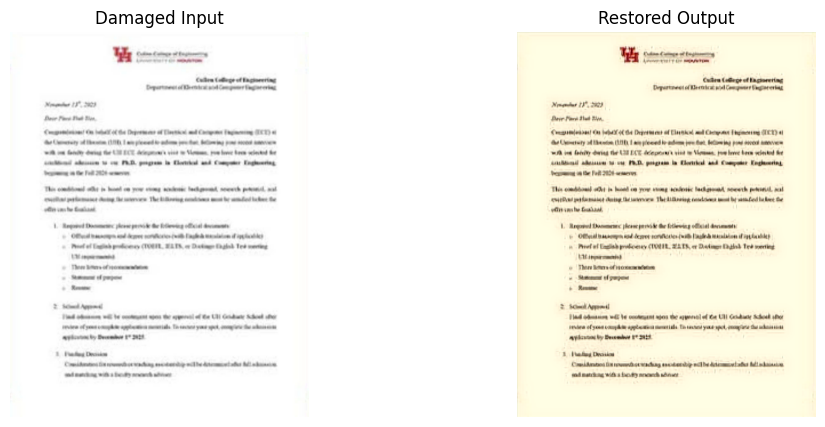


===== 2. z7645747237287_47bb001350a75e6cbaf14500dca54c23.jpg =====


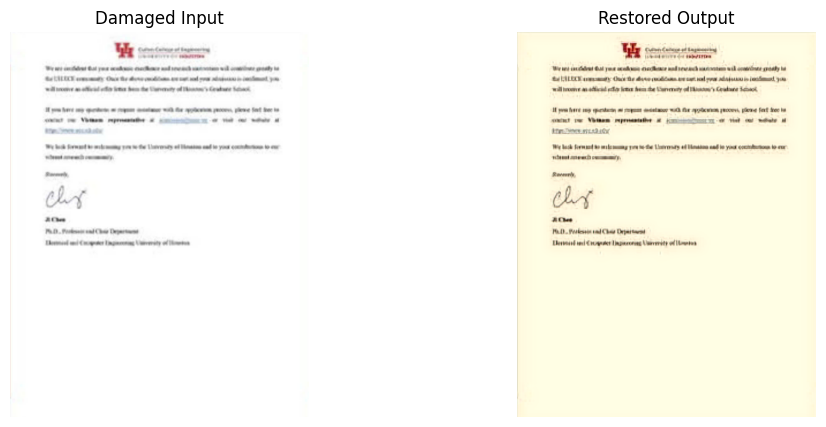

In [ ]:
if __name__ == "__main__":
    inference_and_display(
        model_path="/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_3/Models/best_model.pth",
        test_folder="/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_3/test",
        output_folder="/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_3/restored_results",
        show_results=True
    )